# 22 · Estrategias para Datos Desbalanceados (*Imbalanced Data Strategies*)

En clasificación real, los eventos de interés suelen ser **raros**: fraude, enfermedades, defectos de fabricación.
El problema: un modelo que **siempre predice la clase mayoritaria** puede alcanzar 97 % de *accuracy*… y ser completamente inútil.

En este notebook aprendemos a reconocer y resolver ese problema con cuatro estrategias industriales:

| Estrategia | Idea central |
|---|---|
| Undersampling | Reducir la clase mayoritaria |
| Oversampling | Duplicar la clase minoritaria |
| Class Weights | Penalizar más los errores en la clase rara |
| SMOTE | Generar ejemplos sintéticos con KNN |

Al final construimos un **Pipeline profesional** listo para producción.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.decomposition import PCA

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(42)

# ── Dataset sintético: detección de fraude bancario ──────────────────────────
# 5 000 transacciones, ~3 % son fraude (clase 1)
X_raw, y_raw = make_classification(
    n_samples=5_000,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    weights=[0.97, 0.03],  # 97 % legítimas, 3 % fraude
    flip_y=0.01,
    random_state=42,
)

FEATURE_NAMES = ["monto", "hora", "distancia_comercio", "edad_cliente"]
df = pd.DataFrame(X_raw, columns=FEATURE_NAMES)
df["fraude"] = y_raw

print(f"Total transacciones : {len(df):,}")
print(
    f"Legítimas (0)        : {(df['fraude'] == 0).sum():,}  ({(df['fraude'] == 0).mean():.1%})"
)
print(
    f"Fraude    (1)        : {(df['fraude'] == 1).sum():,}  ({(df['fraude'] == 1).mean():.1%})"
)

Total transacciones : 5,000
Legítimas (0)        : 4,826  (96.5%)
Fraude    (1)        : 174  (3.5%)


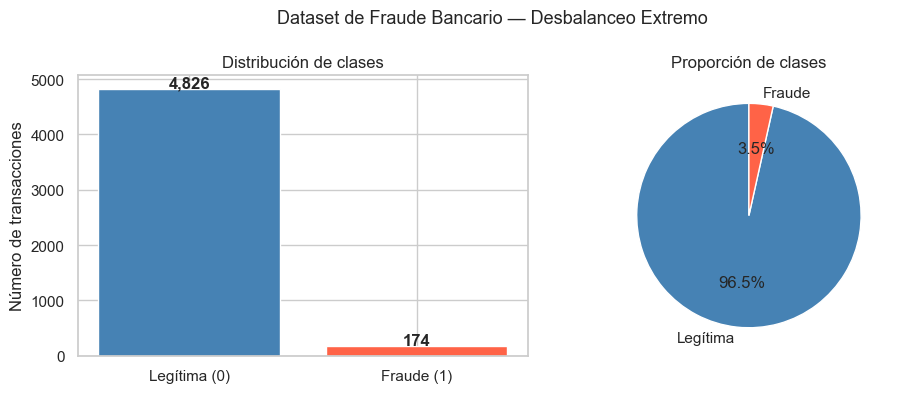

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barra de clases
counts = df["fraude"].value_counts()
axes[0].bar(
    ["Legítima (0)", "Fraude (1)"], counts.values, color=["steelblue", "tomato"]
)
axes[0].set_title("Distribución de clases")
axes[0].set_ylabel("Número de transacciones")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    counts.values,
    labels=["Legítima", "Fraude"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
)
axes[1].set_title("Proporción de clases")

plt.suptitle("Dataset de Fraude Bancario — Desbalanceo Extremo", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
X = df[FEATURE_NAMES].to_numpy()
y = df["fraude"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} filas  |  Test: {len(X_test):,} filas")
print(f"Fraude en train: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Fraude en test:  {y_test.sum()} ({y_test.mean():.1%})")

Train: 3,750 filas  |  Test: 1,250 filas
Fraude en train: 131 (3.5%)
Fraude en test:  43 (3.4%)


---
## 1 · La trampa del *accuracy* (*The Accuracy Trap*)

Entrenamos `LogisticRegression` **sin ninguna estrategia** para datos desbalanceados.
¿Qué pasa?

In [13]:
# ── Modelo base (sin estrategia) ─────────────────────────────────────────────
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("=" * 55)
print("MODELO BASE — sin ninguna estrategia")
print("=" * 55)
print(classification_report(y_test, y_pred_base, target_names=["Legítima", "Fraude"]))

MODELO BASE — sin ninguna estrategia
              precision    recall  f1-score   support

    Legítima       0.98      1.00      0.99      1207
      Fraude       0.81      0.51      0.63        43

    accuracy                           0.98      1250
   macro avg       0.90      0.75      0.81      1250
weighted avg       0.98      0.98      0.98      1250



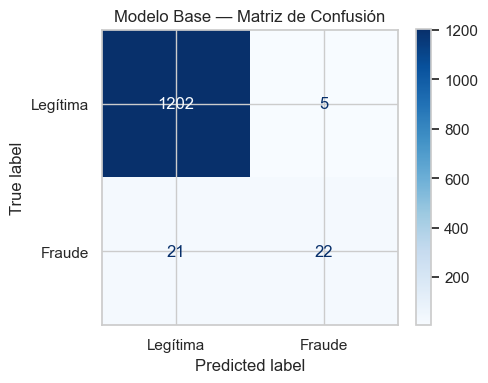


Accuracy : 97.9%  ← parece excelente…
Recall fraude: 51.2%  ← ¡el modelo ignora casi todo el fraude!


In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base, display_labels=["Legítima", "Fraude"], cmap="Blues", ax=ax
)
ax.set_title("Modelo Base — Matriz de Confusión")
plt.tight_layout()
plt.show()

acc = (y_pred_base == y_test).mean()
recall_fraud = recall_score(y_test, y_pred_base)
print(f"\nAccuracy : {acc:.1%}  ← parece excelente…")
print(f"Recall fraude: {recall_fraud:.1%}  ← ¡el modelo ignora casi todo el fraude!")

> **Conclusión:** El modelo acertó ~97 % de las predicciones… pero sólo porque aprendió a decir
> *"todo es legítimo"*. El **recall de fraude** es cercano a 0.
> Accuracy alta ≠ modelo útil cuando los datos están desbalanceados.

---
## 2 · Undersampling (Submuestreo)

**Idea:** reducir la clase mayoritaria hasta igualar la minoritaria.
Entrenamos con menos datos pero con clases equilibradas.

- Pros: simple, rápido, reduce tiempo de entrenamiento
- Cons: **descartas información** de la clase mayoritaria

In [17]:
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(
    f"Antes — Legítimas: {(y_train == 0).sum():,}  |  Fraude: {(y_train == 1).sum():,}"
)
print(
    f"Después — Legítimas: {(y_under == 0).sum():,}  |  Fraude: {(y_under == 1).sum():,}"
)
print(f"Datos totales: {len(y_train):,} → {len(y_under):,}")

Antes — Legítimas: 3,619  |  Fraude: 131
Después — Legítimas: 131  |  Fraude: 131
Datos totales: 3,750 → 262


In [19]:
model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(X_under, y_under)
y_pred_under = model_under.predict(X_test)

print("=" * 55)
print("UNDERSAMPLING")
print("=" * 55)
print(classification_report(y_test, y_pred_under, target_names=["Legítima", "Fraude"]))

UNDERSAMPLING
              precision    recall  f1-score   support

    Legítima       0.99      0.83      0.90      1207
      Fraude       0.15      0.84      0.25        43

    accuracy                           0.83      1250
   macro avg       0.57      0.83      0.58      1250
weighted avg       0.96      0.83      0.88      1250



---
## 3 · Oversampling (Sobremuestreo)

**Idea:** duplicar (con reemplazo / *bootstrap*) la clase minoritaria hasta igualar la mayoritaria.
No se pierde información, pero los ejemplos nuevos son **copias exactas**.

- Pros: no pierdes datos, sencillo
- Cons: riesgo de **overfitting** (el modelo memoriza los duplicados)

In [20]:
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)  # type: ignore[misc]

print(
    f"Antes — Legítimas: {(y_train == 0).sum():,}  |  Fraude: {(y_train == 1).sum():,}"
)
print(
    f"Después — Legítimas: {(y_over == 0).sum():,}  |  Fraude: {(y_over == 1).sum():,}"
)
print(f"Datos totales: {len(y_train):,} → {len(y_over):,}")

Antes — Legítimas: 3,619  |  Fraude: 131
Después — Legítimas: 3,619  |  Fraude: 3,619
Datos totales: 3,750 → 7,238


In [30]:
model_over = LogisticRegression(max_iter=1000, random_state=42)
model_over.fit(X_over, y_over)
y_pred_over = model_over.predict(X_test)

print("=" * 55)
print("OVERSAMPLING")
print("=" * 55)
print(classification_report(y_test, y_pred_over, target_names=["Legítima", "Fraude"]))

OVERSAMPLING
              precision    recall  f1-score   support

    Legítima       0.99      0.85      0.92      1207
      Fraude       0.16      0.81      0.27        43

    accuracy                           0.85      1250
   macro avg       0.58      0.83      0.59      1250
weighted avg       0.96      0.85      0.89      1250



---
## 4 · Class Weights (Pesos de Clase)

**Idea:** no modificamos los datos. Le decimos al modelo que los errores en la clase minoritaria
**cuestan más**. Con `class_weight='balanced'`, sklearn ajusta los pesos automáticamente:

$$w_c = \frac{n\_total}{n\_clases \times n\_c}$$

- Pros: cero cambios en los datos, fácil de activar con un parámetro
- Cons: menos control que el remuestreo

In [22]:
model_weights = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
)
model_weights.fit(X_train, y_train)  # datos ORIGINALES, sin resamplear
y_pred_weights = model_weights.predict(X_test)

print("=" * 55)
print("CLASS WEIGHTS (balanced)")
print("=" * 55)
print(
    classification_report(y_test, y_pred_weights, target_names=["Legítima", "Fraude"])
)

CLASS WEIGHTS (balanced)
              precision    recall  f1-score   support

    Legítima       0.99      0.85      0.92      1207
      Fraude       0.17      0.81      0.27        43

    accuracy                           0.85      1250
   macro avg       0.58      0.83      0.60      1250
weighted avg       0.96      0.85      0.90      1250



---
## 5 · SMOTE — Generación de Datos Sintéticos

### 5.1 · Estandarización (*z-score*) — requisito previo

SMOTE usa **K vecinos más cercanos (KNN)** para generar ejemplos nuevos.
KNN calcula distancias euclidianas entre puntos. Si una variable va de 0 a 1
y otra va de 0 a 1 000 000, la segunda domina completamente el cálculo.

Solución: **estandarizar** con `StandardScaler` antes de aplicar SMOTE.

$$z = \frac{x - \mu}{\sigma}$$

Tras estandarizar, cada variable tiene **media 0 y desviación estándar 1**.

### 5.2 · Cómo funciona SMOTE

Para cada ejemplo de fraude:
1. Encuentra sus **K vecinos más cercanos** (también de fraude)
2. Elige uno al azar
3. Crea un punto **entre ambos**: `nuevo = p1 + λ·(p2 − p1)` con λ ∈ [0,1]

El resultado: ejemplos nuevos que son **plausibles pero no duplicados exactos**.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)  # type: ignore[misc]

print(
    f"Antes — Legítimas: {(y_train == 0).sum():,}  |  Fraude: {(y_train == 1).sum():,}"
)
print(
    f"Después — Legítimas: {(y_smote == 0).sum():,}  |  Fraude: {(y_smote == 1).sum():,}"
)
print(f"\nNota: X_smote ya está estandarizado")

Antes — Legítimas: 3,619  |  Fraude: 131
Después — Legítimas: 3,619  |  Fraude: 3,619

Nota: X_smote ya está estandarizado


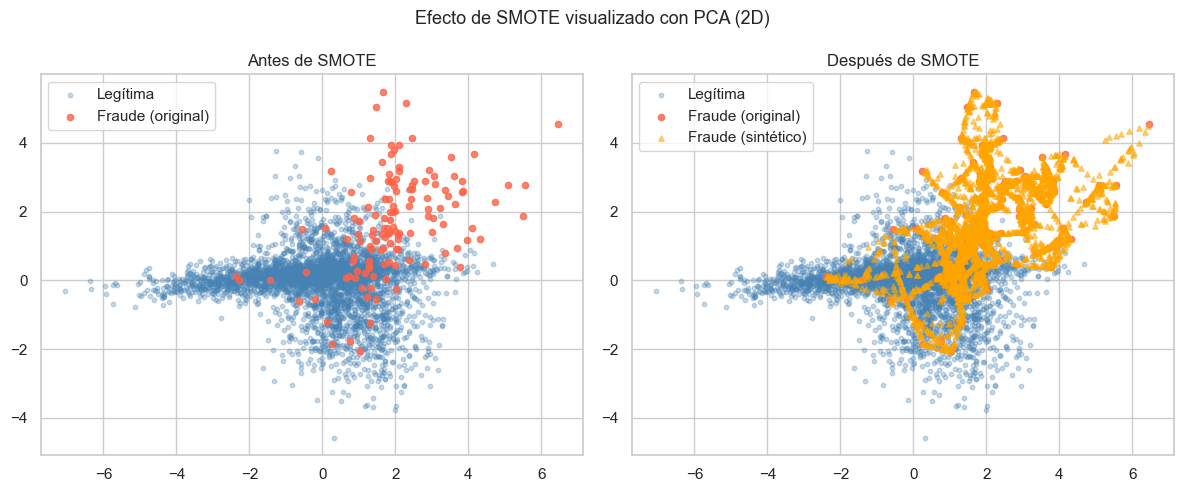

In [25]:
pca = PCA(n_components=2, random_state=42)

# Proyectar train original + SMOTE en 2D
X_vis_orig = pca.fit_transform(X_train_scaled)
X_vis_smote = pca.transform(X_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
mask_leg = y_train == 0
mask_fra = y_train == 1
axes[0].scatter(
    X_vis_orig[mask_leg, 0],
    X_vis_orig[mask_leg, 1],
    alpha=0.3,
    s=10,
    label="Legítima",
    color="steelblue",
)
axes[0].scatter(
    X_vis_orig[mask_fra, 0],
    X_vis_orig[mask_fra, 1],
    alpha=0.8,
    s=20,
    label="Fraude (original)",
    color="tomato",
)
axes[0].set_title("Antes de SMOTE")
axes[0].legend()

# Después de SMOTE
mask_leg_s = y_smote == 0
mask_fra_s = y_smote == 1
n_orig_fraud = mask_fra.sum()
axes[1].scatter(
    X_vis_smote[mask_leg_s, 0],
    X_vis_smote[mask_leg_s, 1],
    alpha=0.3,
    s=10,
    label="Legítima",
    color="steelblue",
)
axes[1].scatter(
    X_vis_smote[mask_fra_s, 0][:n_orig_fraud],
    X_vis_smote[mask_fra_s, 1][:n_orig_fraud],
    alpha=0.8,
    s=20,
    label="Fraude (original)",
    color="tomato",
)
axes[1].scatter(
    X_vis_smote[mask_fra_s, 0][n_orig_fraud:],
    X_vis_smote[mask_fra_s, 1][n_orig_fraud:],
    alpha=0.5,
    s=15,
    label="Fraude (sintético)",
    color="orange",
    marker="^",
)
axes[1].set_title("Después de SMOTE")
axes[1].legend()

plt.suptitle("Efecto de SMOTE visualizado con PCA (2D)", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_smote, y_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print("=" * 55)
print("SMOTE + StandardScaler")
print("=" * 55)
print(classification_report(y_test, y_pred_smote, target_names=["Legítima", "Fraude"]))

SMOTE + StandardScaler
              precision    recall  f1-score   support

    Legítima       0.99      0.86      0.92      1207
      Fraude       0.17      0.81      0.28        43

    accuracy                           0.86      1250
   macro avg       0.58      0.84      0.60      1250
weighted avg       0.96      0.86      0.90      1250



---
## 6 · Comparación de Estrategias

Misma métrica, mismo modelo, mismo conjunto de test. ¿Cuál estrategia conviene usar?

In [28]:
def get_metrics(y_true, y_pred, y_proba=None, name=""):
    return {
        "Estrategia": name,
        "Precision (fraude)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (fraude)": recall_score(y_true, y_pred),
        "F1 (fraude)": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else None,
    }


results = [
    get_metrics(
        y_test, y_pred_base, baseline.predict_proba(X_test)[:, 1], "Sin estrategia"
    ),
    get_metrics(
        y_test, y_pred_under, model_under.predict_proba(X_test)[:, 1], "Undersampling"
    ),
    get_metrics(
        y_test, y_pred_over, model_over.predict_proba(X_test)[:, 1], "Oversampling"
    ),
    get_metrics(
        y_test,
        y_pred_weights,
        model_weights.predict_proba(X_test)[:, 1],
        "Class Weights",
    ),
    get_metrics(
        y_test, y_pred_smote, model_smote.predict_proba(X_test_scaled)[:, 1], "SMOTE"
    ),
]

df_results = pd.DataFrame(results).set_index("Estrategia")
df_results = df_results.round(3)
df_results.style.background_gradient(cmap="YlGn", axis=0)

,Precision (fraude),Recall (fraude),F1 (fraude),ROC-AUC
Estrategia,,,,
Sin estrategia,0.815000,0.512000,0.629000,0.883000
Undersampling,0.149000,0.837000,0.253000,0.890000
Oversampling,0.164000,0.814000,0.272000,0.893000
Class Weights,0.165000,0.814000,0.275000,0.892000
SMOTE,0.170000,0.814000,0.281000,0.892000


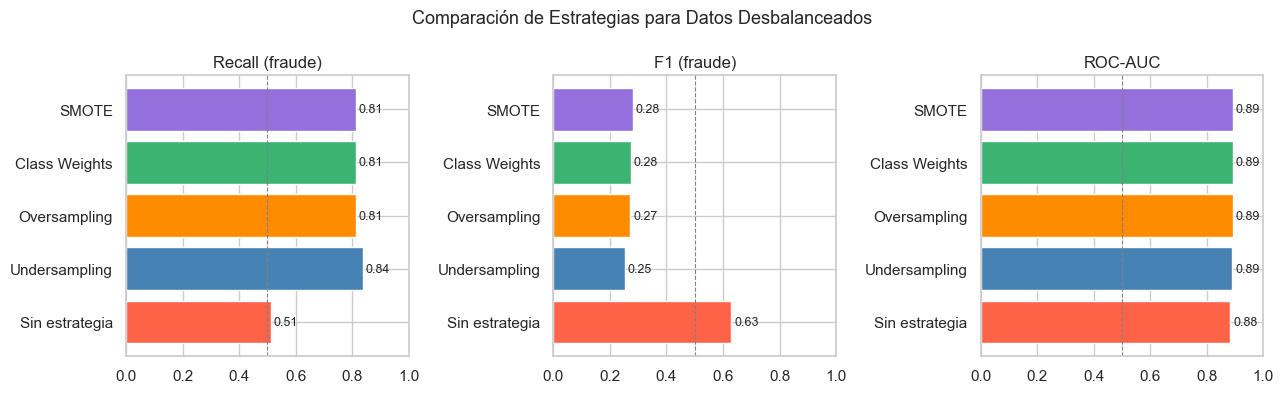

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ["Recall (fraude)", "F1 (fraude)", "ROC-AUC"]
colors = ["tomato", "steelblue", "darkorange", "mediumseagreen", "mediumpurple"]

for ax, metric in zip(axes, metrics):
    bars = ax.barh(df_results.index, df_results[metric], color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(metric)
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(
            val + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            fontsize=9,
        )

plt.suptitle("Comparación de Estrategias para Datos Desbalanceados", fontsize=13)
plt.tight_layout()
plt.show()

### ¿Cuándo usar cada estrategia?

| Estrategia | Cuándo usarla |
|---|---|
| **Class Weights** | Primera opción: sin cambios en los datos, funciona bien con la mayoría de modelos |
| **Undersampling** | Dataset muy grande y el tiempo de entrenamiento importa |
| **Oversampling** | Dataset pequeño, no quieres perder datos |
| **SMOTE** | Oversampling con riesgo de overfitting alto; genera variabilidad sintética |

> **Regla práctica:** empieza siempre con `class_weight='balanced'`. Si no es suficiente, prueba SMOTE.

---
## 7 · Pipeline Profesional (*Production-Ready*)

En producción, **nunca** aplicamos SMOTE sobre el test set ni fuera del pipeline.
`imblearn.pipeline.Pipeline` (no el de sklearn) soporta pasos de remuestreo y garantiza que
SMOTE sólo se aplica en `fit`, nunca en `predict`.

```python
# imblearn.pipeline (no sklearn.pipeline) — acepta resamplers
from imblearn.pipeline import Pipeline as ImbPipeline
```

In [31]:
pipe = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

# GridSearchCV busca el mejor k_neighbors para SMOTE y C para LogisticRegression
param_grid = {
    "smote__k_neighbors": [3, 5, 7],
    "model__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",  # optimizamos F1 sobre la clase positiva (fraude)
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print(f"Mejores parámetros: {grid.best_params_}")
print(f"Mejor F1 en CV:     {grid.best_score_:.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'model__C': 0.01, 'smote__k_neighbors': 5}
Mejor F1 en CV:     0.281


In [32]:
y_pred_pipe = grid.predict(X_test)
y_proba_pipe = grid.predict_proba(X_test)[:, 1]

print("=" * 55)
print("PIPELINE PROFESIONAL (mejor configuración)")
print("=" * 55)
print(classification_report(y_test, y_pred_pipe, target_names=["Legítima", "Fraude"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_pipe):.3f}")

PIPELINE PROFESIONAL (mejor configuración)
              precision    recall  f1-score   support

    Legítima       0.99      0.86      0.92      1207
      Fraude       0.17      0.81      0.29        43

    accuracy                           0.86      1250
   macro avg       0.58      0.84      0.60      1250
weighted avg       0.96      0.86      0.90      1250

ROC-AUC: 0.892


---
## Resumen

1. **Accuracy es engañosa** con datos desbalanceados. Usa Recall, F1 y ROC-AUC.
2. **Class Weights** es la solución más simple y primer punto de partida.
3. **SMOTE** genera ejemplos plausibles con KNN — requiere estandarización previa.
4. **`imblearn.Pipeline`** garantiza que el remuestreo sólo ocurre en entrenamiento.
5. **`GridSearchCV` + `StratifiedKFold`** para optimizar hiperparámetros manteniendo la proporción de clases en cada fold.